# 3、线性回归实战

## 3.1、使用正规方程进行求解

### 3.1.1、简单线性回归

$$y = wx + b$$

一元一次方程，在机器学习中一元表示一个特征，b表示截距，y表示目标值。

一元一次方程真实的斜率和截距是:  [3] [8]
通过正规方程求解的斜率和截距是:  [[3.07]
 [7.36]]


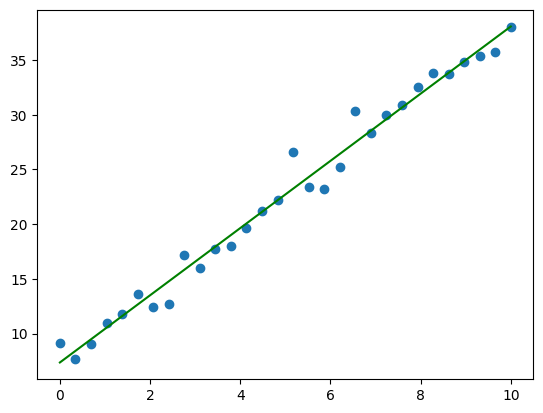

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 转化成矩阵
X = np.linspace(0, 10, num = 30).reshape(-1, 1)

# 斜率和截距，随机生成
w = np.random.randint(1, 5, size = 1)
b = np.random.randint(1, 10, size = 1)

# 根据一元一次方程计算目标值y, 并加上“噪声”, 数据有上下波动~
y = X * w + b + np.random.randn(30, 1)
plt.scatter(X, y)

# 重新构造X, b截距, 相当于系数w0, 前面统一乘以1
X = np.concatenate([X, np.full(shape = (30, 1), fill_value = 1)], axis = 1)

# 正规方程求解
theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y).round(2)

print('一元一次方程真实的斜率和截距是: ', w, b)
print('通过正规方程求解的斜率和截距是: ', theta)

# 根据求解的斜率和截距绘制线性回归线型图
plt.plot(X[:, 0], X.dot(theta), color = 'green')

效果如下(random.randn是随机生成正态分布数据，所以每次执行图形会有所不同)

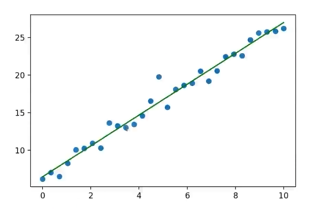

### 3.1.2、多元线性回归

$$y = w_1 x_1 + w_2 x_2 + b$$

二元一次方程，$x_1$、$x_2$ 相当于两个特征，b是方程截距

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D # 绘制三维图像

# 转化成矩阵
x1 = np.random.randint(-150, 150, size = (300, 1))
x2 = np.random.randint(0, 300, size = (300, 1))

# 斜率和截距，随机生成
w = np.random.randint(1, 5, size = 2)
b = np.random.randint(1, 10, size = 1)
# 根据二元一次方程计算目标值y，并加上“噪声”，数据有上下波动~
y = x1 * w[0] + x2 * w[1] + b + np.random.randn(300, 1)
fig = plt.figure(figsize=(9, 6))
ax = Axes3D(fig)
ax.scatter(x1, x2, y) # 三维散点图
ax.view_init(elev=10, azim=-20) # 调整视角

<Figure size 900x600 with 0 Axes>

效果如下：

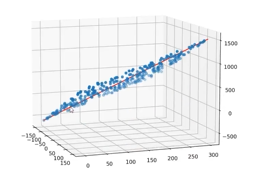

$\Huge W = (X^TX)^{-1}X^Ty$

In [3]:
coef_ = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
w1_ = coef_[0][0]
w2_ = coef_[1][0]
b_ = coef_[2][0]
print(' 正规方程求解的方程的系数：', w1_, w2_, b_)

ValueError: shapes (2,30) and (300,1) not aligned: 30 (dim 1) != 300 (dim 0)

In [ ]:
print(' 真实的方程的系数是：', w, b)

 真实的方程的系数是： [3 3] [7]


In [ ]:
fig = plt.figure(figsize=(9, 6))
ax = Axes3D(fig)
ax.scatter(x1, x2, y, color = 'red') # 三维散点图
ax.view_init(elev=10, azim=-20) # 调整视角

# 特征1  x1
x_axis = np.linspace(-150, 150, num = 500)
# 特征2  x2
y_axis = np.linspace(0, 300, num = 500)
# 方程  斜率：w1_, w2_, 截距：b_
z_axis = x_axis * w1_ + y_axis * w2_ + b

ax.plot(x_axis, y_axis, z_axis, color = 'green', lw = 5)

<Figure size 900x600 with 0 Axes>